In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm

In [ ]:
# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [ ]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = encoder.fit_transform(y_train.reshape(-1,1))
y_test_encoded = encoder.transform(y_test.reshape(-1,1))

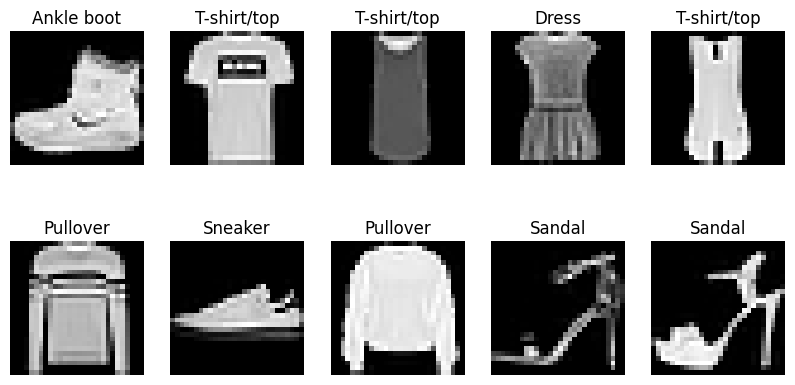

In [ ]:
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
    'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)

    # FIX
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')

    plt.title(classes[y_train[i]])
    plt.axis('off')

plt.show()

In [ ]:
class ConvolutionLayer:

    def __init__(self, num_filters, filter_size):

        self.num_filters = num_filters
        self.filter_size = filter_size

        # Xavier initialization
        self.filters = np.random.randn(
            num_filters,
            filter_size,
            filter_size
        ) / (filter_size * filter_size)

    def iterate_regions(self, image):

        h, w = image.shape

        for i in range(h - self.filter_size + 1):
            for j in range(w - self.filter_size + 1):

                region = image[
                    i:(i + self.filter_size),
                    j:(j + self.filter_size)
                ]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w = input.shape

        output = np.zeros((
            self.num_filters,
            h - self.filter_size + 1,
            w - self.filter_size + 1
        ))

        for region, i, j in self.iterate_regions(input):
            output[:, i, j] = np.sum(region * self.filters, axis=(1,2))

        return output

In [ ]:
class MaxPool:

    def iterate_regions(self, image):

        h, w = image.shape[1], image.shape[2]

        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):

                region = image[:,
                    (i * 2):(i * 2 + 2),
                    (j * 2):(j * 2 + 2)
                ]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w = input.shape[1], input.shape[2]

        output = np.zeros((
            input.shape[0],
            h // 2,
            w // 2
        ))

        for region, i, j in self.iterate_regions(input):
            output[:, i, j] = np.amax(region, axis=(1,2))

        return output

In [ ]:
class Flatten:

    def forward(self, input):

        self.last_input_shape = input.shape

        return input.flatten()

In [ ]:
def softmax(x):

    exp = np.exp(x - np.max(x))

    return exp / np.sum(exp)

In [21]:
class FullyConnected:

    def __init__(self, input_len, nodes):

        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):

        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases

        self.last_totals = totals

        exp = np.exp(totals - np.max(totals))

        return exp / np.sum(exp)

    def backward(self, d_L_d_out, learning_rate):

        for i, gradient in enumerate(d_L_d_out):

            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals)

            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)

            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)

            d_t_d_w = self.last_input

            d_t_d_inputs = self.weights

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]

            d_L_d_b = d_L_d_t

            d_L_d_inputs = d_t_d_inputs @ d_L_d_t

            # Update weights
            self.weights -= learning_rate * d_L_d_w
            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs

In [22]:
    def backward(self, d_L_d_out, learning_rate):

        for i, gradient in enumerate(d_L_d_out):

            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals)
            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)
            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)

            d_t_d_w = self.last_input
            d_t_d_inputs = self.weights

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]
            d_L_d_b = d_L_d_t
            d_L_d_inputs = d_t_d_inputs @ d_L_d_t

            self.weights -= learning_rate * d_L_d_w
            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs

In [23]:
conv = ConvolutionLayer(8, 3)
pool = MaxPool()
flatten = Flatten()
fc = FullyConnected(8 * 13 * 13, 10)

In [24]:
def forward(image, label):

    out = conv.forward(image)
    out = pool.forward(out)
    out = flatten.forward(out)
    out = fc.forward(out)

    loss = -np.log(out[label])
    accuracy = 1 if np.argmax(out) == label else 0

    return out, loss, accuracy

In [25]:
def train(image, label, lr=0.005):

    out, loss, acc = forward(image, label)

    gradient = np.zeros(10)
    gradient[label] = -1 / out[label]

    fc.backward(gradient, lr)

    return loss, acc

In [26]:
train_images = X_train[:5000]
train_labels = y_train[:5000]

In [27]:
epochs = 3

for epoch in range(epochs):

    print('Epoch %d ---' % (epoch + 1))

    loss = 0
    num_correct = 0

    for i, (image, label) in enumerate(
        tqdm(zip(train_images, train_labels), total=len(train_images))
    ):

        # FIXED LINE
        l, acc = train(image, label)

        loss += l
        num_correct += acc

        if (i + 1) % 1000 == 0:

            print(
                '[Step %d] Past 1000 steps: Average Loss %.3f | Accuracy: %d%%' % (
                    i + 1,
                    loss / 1000,
                    num_correct / 10
                )
            )

            loss = 0
            num_correct = 0

Epoch 1 ---


 20%|██        | 1024/5000 [00:06<00:25, 155.57it/s]

[Step 1000] Past 1000 steps: Average Loss 1.818 | Accuracy: 55%


 40%|████      | 2017/5000 [00:14<00:19, 151.89it/s]

[Step 2000] Past 1000 steps: Average Loss 1.309 | Accuracy: 68%


...

[Step 3000] Past 1000 steps: Average Loss 0.718 | Accuracy: 75%


 81%|████████  | 4026/5000 [00:28<00:06, 156.88it/s]

[Step 4000] Past 1000 steps: Average Loss 0.685 | Accuracy: 77%


100%|██████████| 5000/5000 [00:35<00:00, 140.31it/s]

[Step 5000] Past 1000 steps: Average Loss 0.583 | Accuracy: 81%


In [30]:
print('\n--- Testing the CNN ---')

test_loss = 0
test_correct = 0

for image, label in zip(X_test[:1000], y_test[:1000]):
    _, loss, acc = forward(image, label)

    test_loss += loss
    test_correct += acc

print('Test Loss:', test_loss / 1000)
print('Test Accuracy:', test_correct / 1000)


--- Testing the CNN ---
Test Loss: 0.6864397878107771
Test Accuracy: 0.784


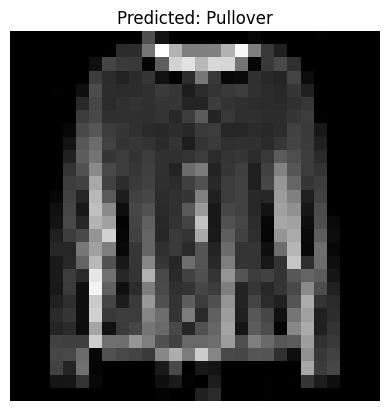

In [32]:
index = 25

image = X_test[index]

prediction, _, _ = forward(image, y_test[index])

predicted_class = np.argmax(prediction)

classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
    'Coat', 'Sandal', 'Shirt', 'Sneaker',
    'Bag', 'Ankle boot'
]

plt.imshow(image, cmap='gray')

plt.title(
    f"Predicted: {classes[predicted_class]}"
)

plt.axis('off')

plt.show()

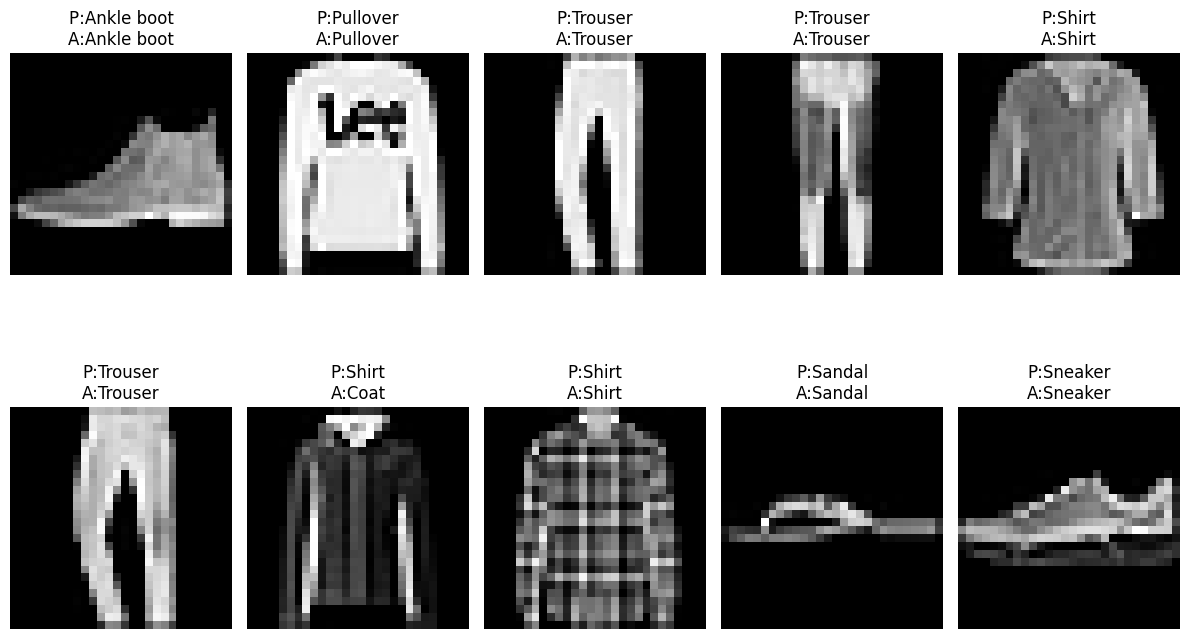

In [33]:
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress',
    'Coat', 'Sandal', 'Shirt', 'Sneaker',
    'Bag', 'Ankle boot'
]

plt.figure(figsize=(12,8))

for i in range(10):

    image = X_test[i]

    prediction, _, _ = forward(image, y_test[i])

    predicted_label = np.argmax(prediction)

    plt.subplot(2,5,i+1)

    plt.imshow(image, cmap='gray')

    plt.title(
        f"P:{classes[predicted_label]}\nA:{classes[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [34]:
correct = 0
total = 1000

for i in range(total):

    image = X_test[i]

    prediction, _, _ = forward(image, y_test[i])

    predicted_label = np.argmax(prediction)

    if predicted_label == y_test[i]:
        correct += 1

accuracy = (correct / total) * 100

print("Final Accuracy:", accuracy, "%")

Final Accuracy: 78.4 %


In [35]:
np.save("fc_weights.npy", fc.weights)
np.save("fc_biases.npy", fc.biases)

print("Weights Saved Successfully")

Weights Saved Successfully


In [36]:
fc.weights = np.load("fc_weights.npy")
fc.biases = np.load("fc_biases.npy")

print("Weights Loaded Successfully")

Weights Loaded Successfully


In [37]:
#FINAL CHECK
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)
